In [53]:
# ── 0. Environment Detection & Setup ───────────────────────────────────────────
import os
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Environment: Google Colab')
    print('Installing neuraloperator...')
    os.system('pip install neuraloperator -q')

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Paths for Colab
    DRIVE_DIR = '/content/drive/MyDrive'
    DATA_DIR  = '/content/data/train'
    CKPT_DIR  = f'{DRIVE_DIR}/checkpoints_v5'

    # Extract data if needed
    if not os.path.exists(DATA_DIR):
        print('Extracting data from Drive...')
        import zipfile
        with zipfile.ZipFile(f'{DRIVE_DIR}/data_upload.zip', 'r') as z:
          z.extractall('/content/')
        print('Done.')
else:
    print('Environment: Local')

    # Paths for local
    DATA_DIR = 'data/train'
    CKPT_DIR = 'checkpoints_v5'

# Create checkpoint directory
os.makedirs(CKPT_DIR, exist_ok=True)

# Verify data exists
if os.path.exists(DATA_DIR):
    n_files = len([f for f in os.listdir(DATA_DIR) if f.endswith('.npz')])
    print(f'Data directory: {DATA_DIR}')
    print(f'Train files: {n_files}')
else:
    raise FileNotFoundError(f'Data not found at: {DATA_DIR}')

print(f'Checkpoints: {CKPT_DIR}')

Environment: Google Colab
Installing neuraloperator...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/data/train
Train files: 6400
Checkpoints: /content/drive/MyDrive/checkpoints_v5


In [54]:
# ── 1. Imports & Device ────────────────────────────────────────────────────────
import glob
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from neuralop.models import FNO
import warnings
warnings.filterwarnings('ignore')

# ── Device Selection: CUDA > MPS > CPU ─────────────────────────────────────────
def get_device():
    """Select best available device with verification."""
    # Try CUDA first (Colab, Linux with NVIDIA GPU)
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f'Device: CUDA ({torch.cuda.get_device_name(0)})')
        print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
        return device

    # Try MPS (Apple Silicon: M1/M2/M3/M4)
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        try:
            device = torch.device('mps')
            # Verify MPS works with a test tensor
            test = torch.zeros(1, device=device)
            del test
            print(f'Device: MPS (Apple Silicon GPU)')
            return device
        except Exception as e:
            print(f'MPS available but failed: {e}')

    # Fallback to CPU
    print('Device: CPU (training will be slow)')
    return torch.device('cpu')

device = get_device()

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

Device: CUDA (Tesla T4)
Memory: 15.6 GB


In [55]:
# ── 2. Dataset — Physics-based Non-dimensional Normalization ───────────────────

class AirfoilDataset(Dataset):
    """
    Loads airfoil CFD data with physics-based normalization.

    Input channels:  [Ux/U_inf, Uy/U_inf, geometry]
    Output channels: [Cp, u*, v*]

    Physics normalization ensures all samples have O(1) scale regardless
    of Reynolds number (which varies 90x across the dataset).
    """

    def __init__(self, data_dir, split='train', val_ratio=0.2):
        assert split in ('train', 'val')

        all_files = sorted(glob.glob(
            os.path.join(data_dir, '**', '*.npz'), recursive=True
        ))
        if not all_files:
            raise FileNotFoundError(f'No .npz files found under: {data_dir}')

        n_val   = max(1, int(len(all_files) * val_ratio))
        n_train = len(all_files) - n_val
        self.files = all_files[:n_train] if split == 'train' else all_files[n_train:]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        arr = np.load(self.files[idx])['a'].astype(np.float32)  # (6, 128, 128)

        # ── Compute flow scalars ───────────────────────────────────────────
        Ux    = float(arr[0].mean())  # Freestream x-velocity
        Uy    = float(arr[1].mean())  # Freestream y-velocity
        U_inf = max(float(np.sqrt(Ux**2 + Uy**2)), 1e-6)  # Freestream speed
        q_inf = max(0.5 * 1.225 * U_inf**2, 1e-6)         # Dynamic pressure

        # ── Far-field static pressure (average of corners) ─────────────────
        p_field = arr[3]
        p_inf = float(np.mean([
            p_field[:8,  :8].mean(),
            p_field[:8,  -8:].mean(),
            p_field[-8:, :8].mean(),
            p_field[-8:, -8:].mean(),
        ]))

        # ── Non-dimensional INPUTS ─────────────────────────────────────────
        inp = np.stack([
            arr[0] / U_inf,  # ~cos(AoA)
            arr[1] / U_inf,  # ~sin(AoA)
            arr[2],          # geometry mask (0/1)
        ], axis=0).astype(np.float32)

        # ── Non-dimensional OUTPUTS ────────────────────────────────────────
        Cp  = (arr[3] - p_inf) / q_inf  # Pressure coefficient
        u_s = arr[4] / U_inf            # Velocity ratio (x)
        v_s = arr[5] / U_inf            # Velocity ratio (y)

        out = np.stack([Cp, u_s, v_s], axis=0).astype(np.float32)

        return torch.from_numpy(inp), torch.from_numpy(out)


# Create datasets
train_ds = AirfoilDataset(DATA_DIR, split='train', val_ratio=0.2)
val_ds   = AirfoilDataset(DATA_DIR, split='val',   val_ratio=0.2)

print(f'Train samples: {len(train_ds)}')
print(f'Val samples:   {len(val_ds)}')

Train samples: 5120
Val samples:   1280


In [56]:
# ── 3. DataLoaders ─────────────────────────────────────────────────────────────
BATCH_SIZE = 16

# num_workers: 2-4 for Colab/Linux, 0 for Mac (fork issues)
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda')
)

print(f'Train batches/epoch: {len(train_loader)}')
print(f'Val batches/epoch:   {len(val_loader)}')

Train batches/epoch: 320
Val batches/epoch:   80


In [57]:
# ── 4. FNO Model ────────────────────────────────────────────────────────────────
#
# Key change from v3: n_modes=(64, 64) instead of (48, 48)
# More Fourier modes = captures higher-frequency features at airfoil surface

model = FNO(
    n_modes=(64, 64),       # Fourier modes (was 48,48 in v3)
    in_channels=3,          # [Ux/U_inf, Uy/U_inf, geometry]
    out_channels=3,         # [Cp, u*, v*]
    hidden_channels=64,
    n_layers=6,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'FNO parameters: {total_params:,}')

# Verify forward pass
with torch.no_grad():
    test_in  = torch.randn(2, 3, 128, 128, device=device)
    test_out = model(test_in)
    print(f'Forward pass: {tuple(test_in.shape)} -> {tuple(test_out.shape)} OK')

FNO parameters: 51,972,739
Forward pass: (2, 3, 128, 128) -> (2, 3, 128, 128) OK


In [58]:
# ── 5. Surface-Weighted Loss Function ──────────────────────────────────────────
#
# KEY INNOVATION IN v5:
# Standard L2 treats all pixels equally, but:
#   - 95% of pixels are far-field (Cp ~ 0) — easy
#   - 5% at airfoil surface have the important physics — hard
# Surface weighting adds extra penalty at the boundary.

# Channel weights (pressure 2x more important)
LOSS_WEIGHTS = torch.tensor([2.0, 1.0, 1.0], device=device)

# Surface weight (extra penalty at airfoil boundary)
SURFACE_WEIGHT = 5.0


def extract_surface_mask(geometry, thickness=2):
    """
    Extract airfoil surface using morphological operations.
    Surface = dilated - eroded (a ring around the boundary).

    Args:
        geometry: (B, H, W) tensor with values in [0, 1]
        thickness: width of the surface band in pixels

    Returns:
        surface_mask: (B, H, W) tensor, 1 at surface, 0 elsewhere
    """
    g = geometry.unsqueeze(1)  # (B, 1, H, W)
    k = 2 * thickness + 1

    # Dilation (max pool expands)
    dilated = F.max_pool2d(g, k, stride=1, padding=thickness)

    # Erosion (min pool = -max(-x) shrinks)
    eroded = -F.max_pool2d(-g, k, stride=1, padding=thickness)

    # Surface is the difference
    surface = torch.clamp(dilated - eroded, 0, 1).squeeze(1)

    return surface


def surface_weighted_loss(pred, target, geometry, eps=1e-8):
    """
    Combined loss: weighted relative L2 + extra surface Cp penalty.

    Args:
        pred: (B, 3, H, W) predicted [Cp, u*, v*]
        target: (B, 3, H, W) ground truth
        geometry: (B, H, W) airfoil mask

    Returns:
        total_loss, rel_l2_loss, surface_loss
    """
    B, C, H, W = pred.shape
    w = LOSS_WEIGHTS.view(1, C, 1, 1)

    # ── Part 1: Weighted Relative L2 ───────────────────────────────────────
    diff  = (pred - target) * w
    num   = diff.pow(2).sum(dim=(-2, -1)).sqrt()          # (B, C)
    denom = (target * w).pow(2).sum(dim=(-2, -1)).sqrt()  # (B, C)
    rel_l2 = (num / (denom + eps)).mean()

    # ── Part 2: Surface Cp Penalty ─────────────────────────────────────────
    surface_mask = extract_surface_mask(geometry, thickness=2)

    cp_pred   = pred[:, 0]    # (B, H, W)
    cp_target = target[:, 0]

    cp_surface_err = ((cp_pred - cp_target) * surface_mask).pow(2)
    n_surface = surface_mask.sum() + eps
    surface_loss = cp_surface_err.sum() / n_surface

    # ── Combined ───────────────────────────────────────────────────────────
    total = rel_l2 + SURFACE_WEIGHT * surface_loss

    return total, rel_l2, surface_loss


# ── Test loss function ─────────────────────────────────────────────────────────
x_test, y_test = next(iter(train_loader))
x_test, y_test = x_test.to(device), y_test.to(device)
geom_test = x_test[:, 2]

total, rel, surf = surface_weighted_loss(y_test, y_test, geom_test)
print(f'Loss (identical): total={total.item():.6f}, rel={rel.item():.6f}, surf={surf.item():.6f}')

total, rel, surf = surface_weighted_loss(torch.randn_like(y_test), y_test, geom_test)
print(f'Loss (random):    total={total.item():.4f}, rel={rel.item():.4f}, surf={surf.item():.4f}')

Loss (identical): total=0.000000, rel=0.000000, surf=0.000000
Loss (random):    total=12.5688, rel=5.6416, surf=1.3854


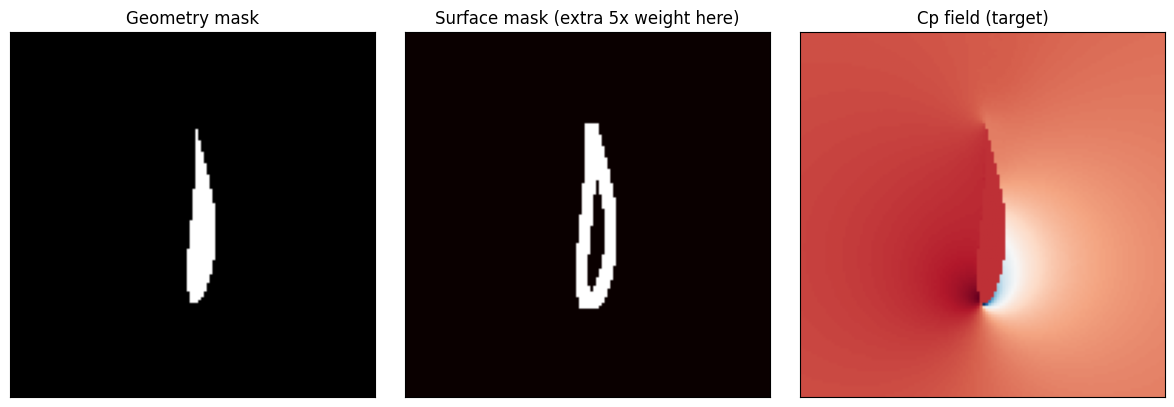

In [59]:
# ── 6. Visualize Surface Mask ──────────────────────────────────────────────────
surface = extract_surface_mask(geom_test[:1], thickness=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(geom_test[0].cpu(), cmap='gray', origin='lower')
axes[0].set_title('Geometry mask')
axes[1].imshow(surface[0].cpu(), cmap='hot', origin='lower')
axes[1].set_title('Surface mask (extra 5x weight here)')
axes[2].imshow(y_test[0, 0].cpu(), cmap='RdBu_r', origin='lower')
axes[2].set_title('Cp field (target)')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [60]:
# ── 7. Optimizer & Scheduler ───────────────────────────────────────────────────
#
# Changes from v3:
#   - 100 epochs (was 50) — model was still improving
#   - Lower eta_min: 1e-6 (was 1e-5)
#   - Longer warmup: 10 epochs (was 5)

N_EPOCHS      = 100
LR            = 1e-3
WARMUP_EPOCHS = 10
PATIENCE      = 20

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print(f'Optimizer:     AdamW (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler:     Warmup({WARMUP_EPOCHS}) -> CosineAnnealing')
print(f'Epochs:        {N_EPOCHS} (early stop patience: {PATIENCE})')
print(f'Surface weight: {SURFACE_WEIGHT}x extra on Cp at boundary')

Optimizer:     AdamW (lr=0.001, weight_decay=1e-4)
Scheduler:     Warmup(10) -> CosineAnnealing
Epochs:        100 (early stop patience: 20)
Surface weight: 5.0x extra on Cp at boundary


In [ ]:
# ── 8. Training Loop with Progress Bars ────────────────────────────────────────

# Custom gradient clipping that handles complex tensors (needed for FNO on MPS)
def clip_grad_norm_complex_(parameters, max_norm):
    """
    Clip gradients supporting complex tensors (FNO uses complex FFT weights).
    Standard torch.nn.utils.clip_grad_norm_ fails on MPS with complex grads.
    """
    parameters = [p for p in parameters if p.grad is not None]
    if len(parameters) == 0:
        return torch.tensor(0.0)

    # Compute total norm, handling complex tensors
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad.is_complex():
            # For complex: norm = sqrt(sum(|z|^2)) = sqrt(sum(real^2 + imag^2))
            grad_norm_sq = p.grad.real.pow(2).sum() + p.grad.imag.pow(2).sum()
        else:
            grad_norm_sq = p.grad.pow(2).sum()
        total_norm_sq += grad_norm_sq.item()

    total_norm = total_norm_sq ** 0.5

    # Clip
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in parameters:
            p.grad.detach().mul_(clip_coef)

    return total_norm


print(f'\nCheckpoints -> {CKPT_DIR}')
print(f'Training FNO v5 on {device}...')
print('=' * 70)

train_losses     = []
val_losses       = []
train_rel_losses = []
train_surf_losses = []
best_val         = float('inf')
epochs_no_improve = 0

# Epoch progress bar
epoch_pbar = tqdm(range(1, N_EPOCHS + 1), desc='Training', unit='epoch')

for epoch in epoch_pbar:
    t0 = time.time()

    # ════════════════════════════════════════════════════════════════════════
    # TRAIN
    # ════════════════════════════════════════════════════════════════════════
    model.train()
    epoch_total, epoch_rel, epoch_surf = 0.0, 0.0, 0.0

    train_pbar = tqdm(
        train_loader,
        desc=f'Ep {epoch:>3d} train',
        leave=False,
        unit='batch'
    )

    for x_batch, y_batch in train_pbar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        geometry = x_batch[:, 2]

        optimizer.zero_grad()
        pred = model(x_batch)

        total_loss, rel_loss, surf_loss = surface_weighted_loss(
            pred, y_batch, geometry
        )

        total_loss.backward()

        # Use custom clipping that handles complex gradients (FNO + MPS)
        clip_grad_norm_complex_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_total += total_loss.item()
        epoch_rel   += rel_loss.item()
        epoch_surf  += surf_loss.item()

        train_pbar.set_postfix(loss=f'{total_loss.item():.4f}')

    epoch_total /= len(train_loader)
    epoch_rel   /= len(train_loader)
    epoch_surf  /= len(train_loader)

    # ════════════════════════════════════════════════════════════════════════
    # VALIDATE
    # ════════════════════════════════════════════════════════════════════════
    model.eval()
    epoch_val = 0.0

    val_pbar = tqdm(
        val_loader,
        desc=f'Ep {epoch:>3d} val  ',
        leave=False,
        unit='batch'
    )

    with torch.no_grad():
        for x_batch, y_batch in val_pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            geometry = x_batch[:, 2]
            pred = model(x_batch)

            _, rel_loss, _ = surface_weighted_loss(pred, y_batch, geometry)
            epoch_val += rel_loss.item()

    epoch_val /= len(val_loader)

    # ════════════════════════════════════════════════════════════════════════
    # LOGGING & CHECKPOINTS
    # ════════════════════════════════════════════════════════════════════════
    scheduler.step()
    train_losses.append(epoch_total)
    val_losses.append(epoch_val)
    train_rel_losses.append(epoch_rel)
    train_surf_losses.append(epoch_surf)

    lr_now = optimizer.param_groups[0]['lr']
    epoch_pbar.set_postfix({
        'train': f'{epoch_total:.4f}',
        'val': f'{epoch_val:.4f}',
        'best': f'{best_val:.4f}',
        'lr': f'{lr_now:.1e}'
    })

    # Save best model
    if epoch_val < best_val:
        best_val = epoch_val
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss': best_val,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'config': {
                'n_modes': (64, 64),
                'hidden_channels': 64,
                'n_layers': 6,
                'surface_weight': SURFACE_WEIGHT,
            }
        }, os.path.join(CKPT_DIR, 'best_model_v5.pt'))
        tqdm.write(f'  [Epoch {epoch}] New best: val={best_val:.4f} -> saved')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            tqdm.write(f'  Early stopping at epoch {epoch}')
            break

    # Periodic checkpoint
    if epoch % 20 == 0:
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_loss': epoch_val,
        }, os.path.join(CKPT_DIR, f'checkpoint_epoch{epoch:03d}.pt'))
        tqdm.write(f'  [Epoch {epoch}] Checkpoint saved')

print('=' * 70)
print(f'Done. Best validation loss: {best_val:.4f}')
print(f'Epochs trained: {len(train_losses)}')


Checkpoints -> /content/drive/MyDrive/checkpoints_v5
Training FNO v5 on cuda...


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Ep   1 train:   0%|          | 0/320 [00:00<?, ?batch/s]

Ep   1 val  :   0%|          | 0/80 [00:00<?, ?batch/s]

  [Epoch 1] New best: val=0.5181 -> saved


...

Ep  69 val  :   0%|          | 0/80 [00:00<?, ?batch/s]

  [Epoch 69] New best: val=0.1296 -> saved


Ep  70 train:   0%|          | 0/320 [00:00<?, ?batch/s]

Ep  70 val  :   0%|          | 0/80 [00:00<?, ?batch/s]

Ep  71 train:   0%|          | 0/320 [00:00<?, ?batch/s]